# Part 1: character GPT from scratch

Srinidhi, Lab Pair 49, seed 2342. The preserved complete desktop training run appears below. This notebook loads the saved weights and executes preprocessing, causal masking, and inference checks. It displays training evidence without starting another training run. The complete implementation is in `gpt.py`.

In [1]:
from pathlib import Path
import os, sys, json, hashlib, inspect
import pandas as pd
import torch
from IPython.display import display, Image, Code
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "pyproject.toml").is_file() and (p / "src/lab1").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Extract the complete Part 1 folder and open this notebook inside it.")
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
from lab1 import gpt
MEMBER = ROOT / "task1_llm/srinidhi"
RUN = ROOT / 'reproducibility/raw_logs/srinidhi/desktop-20261001/part1-full'
summary = json.loads((RUN / "summary.json").read_text(encoding="utf-8"))
config = json.loads((RUN / "config.json").read_text(encoding="utf-8"))
history = json.loads((RUN / "history.json").read_text(encoding="utf-8"))
assert summary["is_final_training_run"] and summary["completed_full_epochs"] >= 10
torch.set_num_threads(2)
display({"training_device": summary["device_name"], "torch": summary["torch_version"],
         "cuda": summary["cuda_version"], "epochs": summary["completed_full_epochs"],
         "training_stories": summary["train_stories"], "validation_stories": summary["validation_stories"],
         "parameter_count": summary["parameter_count"], "precision": summary["precision_dtype"]})
display(config)

{'training_device': 'NVIDIA GeForce RTX 5090',
 'torch': '2.11.0+cu128',
 'cuda': '12.8',
 'epochs': 12,
 'training_stories': 100000,
 'validation_stories': 10000,
 'parameter_count': 1427904,
 'precision': 'torch.bfloat16'}

{'mode': 'full',
 'seed': 2342,
 'dataset': 'roneneldan/TinyStories',
 'dataset_revision': 'main',
 'selection': 'indexed_permutation',
 'shuffle_buffer': 1000,
 'data_cache': 'task1_llm/srinidhi/data_processed/full',
 'raw_data_cache': 'task1_llm/data/huggingface',
 'offline': False,
 'train_stories': 100000,
 'validation_stories': 10000,
 'layers': 3,
 'heads': 6,
 'embedding_dim': 192,
 'feedforward_dim': 768,
 'context_length': 256,
 'dropout': 0.15,
 'batch_size': 256,
 'learning_rate': 0.0004,
 'adam_betas': [0.9, 0.95],
 'weight_decay': 0.01,
 'warmup_fraction': 0.05,
 'minimum_lr_ratio': 0.1,
 'epochs': 12,
 'max_steps': None,
 'gradient_clip': 1.0,
 'mixed_precision': True,
 'deterministic': True,
 'num_workers': 0,
 'cpu_threads': 2,
 'log_every_steps': 50,
 'checkpoint_every_steps': 250,
 'generation_prompts': 5,
 'generation_characters': 256,
 'temperature': 0.8,
 'top_k': 40}

## Preprocessing and fixed input–target windows

TinyStories uses this member's seeded permutation of the official training and validation splits. After normalizing line endings and outer whitespace, empty/duplicate stories are excluded across both splits. The frozen split records each source index and the normalized story's SHA256. The vocabulary contains training Unicode characters plus PAD, UNK, BOS, and EOS. Unseen validation characters map to UNK. Each story receives BOS/EOS tokens and fixed context windows; targets shift inputs by one position. Final windows pad on the right, and cross-entropy ignores PAD. Windows never cross stories, and each character/EOS target is scored once per epoch.

In [2]:
vocabulary = json.loads((RUN / "vocabulary.json").read_text(encoding="utf-8"))
char_to_idx = {char: index for index, char in enumerate(vocabulary["tokens"])}
idx_to_char = {index: char for char, index in char_to_idx.items()}
assert all(idx_to_char[char_to_idx[char]] == char for char in vocabulary["tokens"])
with pd.option_context("display.max_rows", None):
    display(pd.DataFrame({"idx": list(idx_to_char), "char": list(idx_to_char.values())}))
cache = gpt.data_cache_paths(config)
with (ROOT / cache["train"]).open(encoding="utf-8") as handle:
    first_story = json.loads(next(handle))["text"]
windows = gpt.StoryWindows([first_story], vocabulary, config["context_length"])
x, y = windows[0]
encoded = [gpt.BOS] + [char_to_idx.get(char, gpt.UNK) for char in first_story] + [gpt.EOS]
valid = y.ne(gpt.PAD)
count = int(valid.sum())
assert x[valid].tolist() == encoded[:count]
assert y[valid].tolist() == encoded[1:count+1]
assert sum(int(windows[index][1].ne(gpt.PAD).sum()) for index in range(len(windows))) == len(first_story)+1
print("First normalized training story:", first_story[:300])
display(pd.DataFrame({"input_id": x[:24].tolist(), "input_char": [idx_to_char[int(i)] for i in x[:24]],
                      "target_id": y[:24].tolist(), "target_char": [idx_to_char[int(i)] for i in y[:24]]}))
print("Character dictionaries invert correctly; shifted targets and complete single-story coverage verified.")
print("Validation characters mapped to UNK:", summary["validation_unknown_characters"],
      "of", summary["validation_character_count"])

,idx,char
0,0,<PAD>
1,1,<UNK>
2,2,<BOS>
3,3,<EOS>
4,4,\n
5,5,
6,6,!
7,7,""""
8,8,$
9,9,&


First normalized training story: Lily and Tom were playing in the park. They saw a big crane lifting heavy things. They wanted to see it closer.

"Let's go to the crane," Tom said. "Maybe we can touch it."

"No, Tom, that's not safe," Lily said. "Mommy said we have to stay away from the crane. It can hurt us."

But Tom did not list


,input_id,input_char,target_id,target_char
0,2,<BOS>,46,L
1,46,L,73,i
2,73,i,76,l
3,76,l,89,y
4,89,y,5,
5,5,,65,a
6,65,a,78,n
7,78,n,68,d
8,68,d,5,
9,5,,54,T


Character dictionaries invert correctly; shifted targets and complete single-story coverage verified.
Validation characters mapped to UNK: 4 of 8708099


## Decoder architecture and training implementation

The decoder sums learned character and learned position embeddings. Each pre-normalized block applies manual multi-head attention followed by a GELU feed-forward network; both sublayers have residual connections. The attention code explicitly projects Q/K/V, computes scaled QKᵀ, fills future positions with −∞, applies softmax and dropout, multiplies by V, and joins/projects heads. The final normalization and linear language head produce next-character logits. No built-in Transformer or attention module is used.

AdamW minimizes next-character cross-entropy. The learning rate ramps linearly during the configured warm-up fraction, then follows cosine decay to the configured minimum ratio. Gradient clipping and finite loss/gradient checks guard the optimization. Mixed precision is disclosed in the config and hardware outputs.

In [3]:
for component in (gpt.StoryWindows, gpt.ManualCausalAttention, gpt.TransformerBlock,
                  gpt.CharacterGPT, gpt.evaluate, gpt.generate, gpt.run):
    print(component.__name__)
    display(Code(inspect.getsource(component), language="python"))

StoryWindows


class StoryWindows(Dataset):
    """Each next-character/EOS target appears once per story in one epoch.

    Windows do not cross stories. Adjacent windows share a single input/target
    boundary character, but no target is scored twice. Final windows are padded.
    """

    def __init__(self, stories: list[str], vocabulary: dict[str, Any], context_length: int):
        if context_length < 1:
            raise ValueError("context_length must be positive")
        self.context_length = context_length
        self.stoi = {char: i for i, char in enumerate(vocabulary["tokens"])}
        dtype = np.uint16 if len(self.stoi) <= 65535 else np.uint32
        self.encoded: list[np.ndarray] = []
        self.windows: list[tuple[int, int]] = []
        self.unknown_characters = 0
        self.character_count = 0
        self.target_count = 0
        for story_index, story in enumerate(stories):
            values = [self.stoi.get(char, UNK) for char in story]
            self.unknown_characters += values.count(UNK)
            self.character_count += len(values)
            encoded = np.asarray([BOS, *values, EOS], dtype=dtype)
            self.encoded.append(encoded)
            self.target_count += len(encoded) - 1
            self.windows.extend((story_index, start)
                                for start in range(0, len(encoded) - 1, context_length))

    def __len__(self) -> int:
        return len(self.windows)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        story_index, start = self.windows[index]
        sequence = self.encoded[story_index]
        count = min(self.context_length, len(sequence) - start - 1)
        x = torch.full((self.context_length,), PAD, dtype=torch.long)
        y = torch.full((self.context_length,), PAD, dtype=torch.long)
        x[:count] = torch.as_tensor(sequence[start:start + count].astype(np.int64))
        y[:count] = torch.as_tensor(sequence[start + 1:start + count + 1].astype(np.int64))
        return x, y

ManualCausalAttention


class ManualCausalAttention(nn.Module):
    def __init__(self, width: int, heads: int, context_length: int, dropout: float):
        super().__init__()
        if width % heads:
            raise ValueError("Embedding width must be divisible by head count")
        self.heads = heads
        self.head_dim = width // heads
        self.qkv = nn.Linear(width, 3 * width)
        self.projection = nn.Linear(width, width)
        self.attention_dropout = nn.Dropout(dropout)
        self.output_dropout = nn.Dropout(dropout)
        self.register_buffer("causal_mask", torch.tril(torch.ones(
            context_length, context_length, dtype=torch.bool)), persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch, length, width = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(batch, length, self.heads, self.head_dim).transpose(1, 2)
        k = k.view(batch, length, self.heads, self.head_dim).transpose(1, 2)
        v = v.view(batch, length, self.heads, self.head_dim).transpose(1, 2)
        # Explicit matrix products, scaling, triangular mask, softmax and AV.
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        scores = scores.float().masked_fill(~self.causal_mask[:length, :length], float("-inf"))
        probabilities = self.attention_dropout(F.softmax(scores, dim=-1)).to(v.dtype)
        attended = (probabilities @ v).transpose(1, 2).contiguous().view(batch, length, width)
        return self.output_dropout(self.projection(attended))

TransformerBlock


...

@torch.no_grad()
def evaluate(model: CharacterGPT, loader: DataLoader, device: torch.device,
             amp: bool = False, dtype: torch.dtype = torch.float16) -> dict[str, Any]:
    model.eval()
    loss_sum, tokens, correct = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with _autocast(amp, dtype):
            logits = model(x)
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), y.reshape(-1),
                                   ignore_index=PAD, reduction="sum")
        mask = y.ne(PAD)
        loss_sum += float(loss.item())
        tokens += int(mask.sum().item())
        correct += int(((logits.argmax(-1) == y) & mask).sum().item())
    if not math.isfinite(loss_sum):
        raise FloatingPointError("Nonfinite validation loss")
    return _metric(loss_sum, tokens, correct)

generate


@torch.no_grad()
def generate(model: CharacterGPT, vocabulary: dict[str, Any], prompt: str,
             max_new_characters: int, device: torch.device, seed: int,
             temperature: float = 0.8, top_k: int = 40) -> str:
    model.eval()
    tokens = vocabulary["tokens"]
    stoi = {char: i for i, char in enumerate(tokens)}
    sequence = [BOS] + [stoi.get(c, UNK) for c in prompt]
    generator = torch.Generator(device=device).manual_seed(seed)
    generated = []
    for _ in range(max_new_characters):
        x = torch.tensor([sequence[-model.context_length:]], dtype=torch.long, device=device)
        logits = model(x)[0, -1].float()
        logits[[PAD, UNK, BOS]] = float("-inf")
        if temperature == 0:
            next_id = int(logits.argmax().item())
        else:
            logits = logits / temperature
            if top_k > 0:
                cutoff = torch.topk(logits, min(top_k, logits.numel())).values[-1]
                logits[logits < cutoff] = float("-inf")
            next_id = int(torch.multinomial(F.softmax(logits, dim=-1), 1, generator=generator).item())
        sequence.append(next_id)
        if next_id == EOS:
            break
        generated.append(tokens[next_id])
    return "".join(generated)

run


def run(config: dict, output_dir: Path, device: str, resume: Path | None = None) -> dict:
    """Train/evaluate one explicitly labeled mode; no cloud resources are created."""
    config = dict(config)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    metrics_path = output_dir / "metrics.jsonl"
    if not resume and metrics_path.exists():
        raise FileExistsError("Output already contains training metrics; use a new directory or resume")
    started = time.perf_counter()
    target = torch.device(device)
    if target.type == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA was requested but is unavailable; refusing a silent CPU fallback")
    if config["mode"] == "full":
        if config["epochs"] < 10 or config["train_stories"] < 100000 or config["validation_stories"] < 10000:
            raise ValueError("Full mode requires >=10 epochs, 100K train stories and 10K validation stories")
        if config.get("max_steps") is not None or config["dataset"] == "synthetic":
            raise ValueError("Full mode must use actual data with no step cap")
    seed_everything(config["seed"], config["deterministic"])
    if config.get("cpu_threads"):
        torch.set_num_threads(config["cpu_threads"])
    if target.type == "cuda":
        torch.cuda.reset_peak_memory_stats(target)
    checkpoint = load_checkpoint(Path(resume), "cpu") if resume else None
    if checkpoint and _resume_contract(checkpoint["config"]) != _resume_contract(config):
        raise ValueError("Resume config must match the saved model, schedule and data contract")
    train_stories, valid_stories, manifest = prepare_data(config, checkpoint["data_manifest"] if checkpoint else None)
    vocabulary = build_vocabulary(train_stories)
    if checkpoint and checkpoint["vocabulary"] != vocabulary:
        raise ValueError("Rebuilt character vocabulary differs from saved vocabulary")
    _json(output_dir / "config.json", config)
    _json(output_dir / "data_manifest.json", manifest)
    _json(output_dir / "vocabulary.json", vocabulary)
    train_data = StoryWindows(train_stories, vocabulary, config["context_length"])
    valid_data = StoryWindows(valid_stories, vocabulary, config["context_length"])
    batches_per_epoch = math.ceil(len(train_data) / config["batch_size"])
    total_steps = batches_per_epoch * config["epochs"]
    planned_steps = min(total_steps, config["max_steps"]) if config.get("max_steps") else total_steps
    warmup_steps = max(1, int(planned_steps * config["warmup_fraction"]))
    model = CharacterGPT(len(vocabulary["tokens"]), config).to(target)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"],
                                  betas=tuple(config["adam_betas"]), weight_decay=config["weight_decay"])

    def lr_factor(step: int) -> float:
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = min(1.0, (step - warmup_steps) / max(1, planned_steps - warmup_steps))
        floor = config["minimum_lr_ratio"]
        return floor + (1 - floor) * 0.5 * (1 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_factor)
    amp, amp_dtype = _precision(config, target)
    scaler = torch.amp.GradScaler("cuda", enabled=amp and amp_dtype == torch.float16)
    resume_scaler_status = "not_resumed"
    state = {"epoch": 0, "next_batch": 0, "global_step": 0, "best_validation_loss": float("inf"),
             "accumulator": _empty_accumulator(), "history": [], "total_training_seconds": 0.0,
             "total_training_targets": 0, "elapsed_seconds_before_resume": 0.0,
             "evaluation_pending": False}
    if checkpoint:
        model.load_state_dict(checkpoint["model"])
        optimizer.load_state_dict(checkpoint["optimizer"])
        for optimizer_state in optimizer.state.values():
            for key, value in optimizer_state.items():
                if isinstance(value, torch

## All measured metrics and complete epoch history

Perplexity is exp(cross-entropy), and bits per character is cross-entropy/ln(2). PAD targets are excluded; EOS and mapped UNK targets are included. The generalization gap is validation eval-mode CE minus online training-mode CE for the selected checkpoint epoch. Distinct-1/2/3 and repeated 4-gram rate use lowercase word n-grams in continuations, excluding prompts. Reported timing/memory describe training on the recorded GPU. Fresh inference checks below have separate timing and do not replace those metrics.

,split,metric,value
0,train,cross_entropy,7.982890e-01
1,train,perplexity,2.221736e+00
2,train,bits_per_character,1.151688e+00
3,train,next_character_accuracy,7.486860e-01
4,train,scored_targets_including_eos,8.957479e+07
5,validation,cross_entropy,7.211013e-01
6,validation,perplexity,2.056697e+00
7,validation,bits_per_character,1.040329e+00
8,validation,next_character_accuracy,7.731199e-01
9,validation,scored_targets_including_eos,8.718099e+06


,epoch,complete,train_ce,validation_ce,validation_perplexity,validation_accuracy
0,1,True,1.969528,1.058222,2.881243,0.671184
1,2,True,1.042560,0.874187,2.396925,0.727652
2,3,True,0.926166,0.805499,2.237813,0.748240
3,4,True,0.877513,0.776953,2.174836,0.756897
4,5,True,0.852514,0.760172,2.138644,0.761732
5,6,True,0.836334,0.748944,2.114765,0.765043
6,7,True,0.824593,0.738345,2.092470,0.767908
7,8,True,0.815730,0.733171,2.081671,0.769492
8,9,True,0.808977,0.726702,2.068249,0.771311
9,10,True,0.804030,0.724414,2.063522,0.772143


learning_curves.png


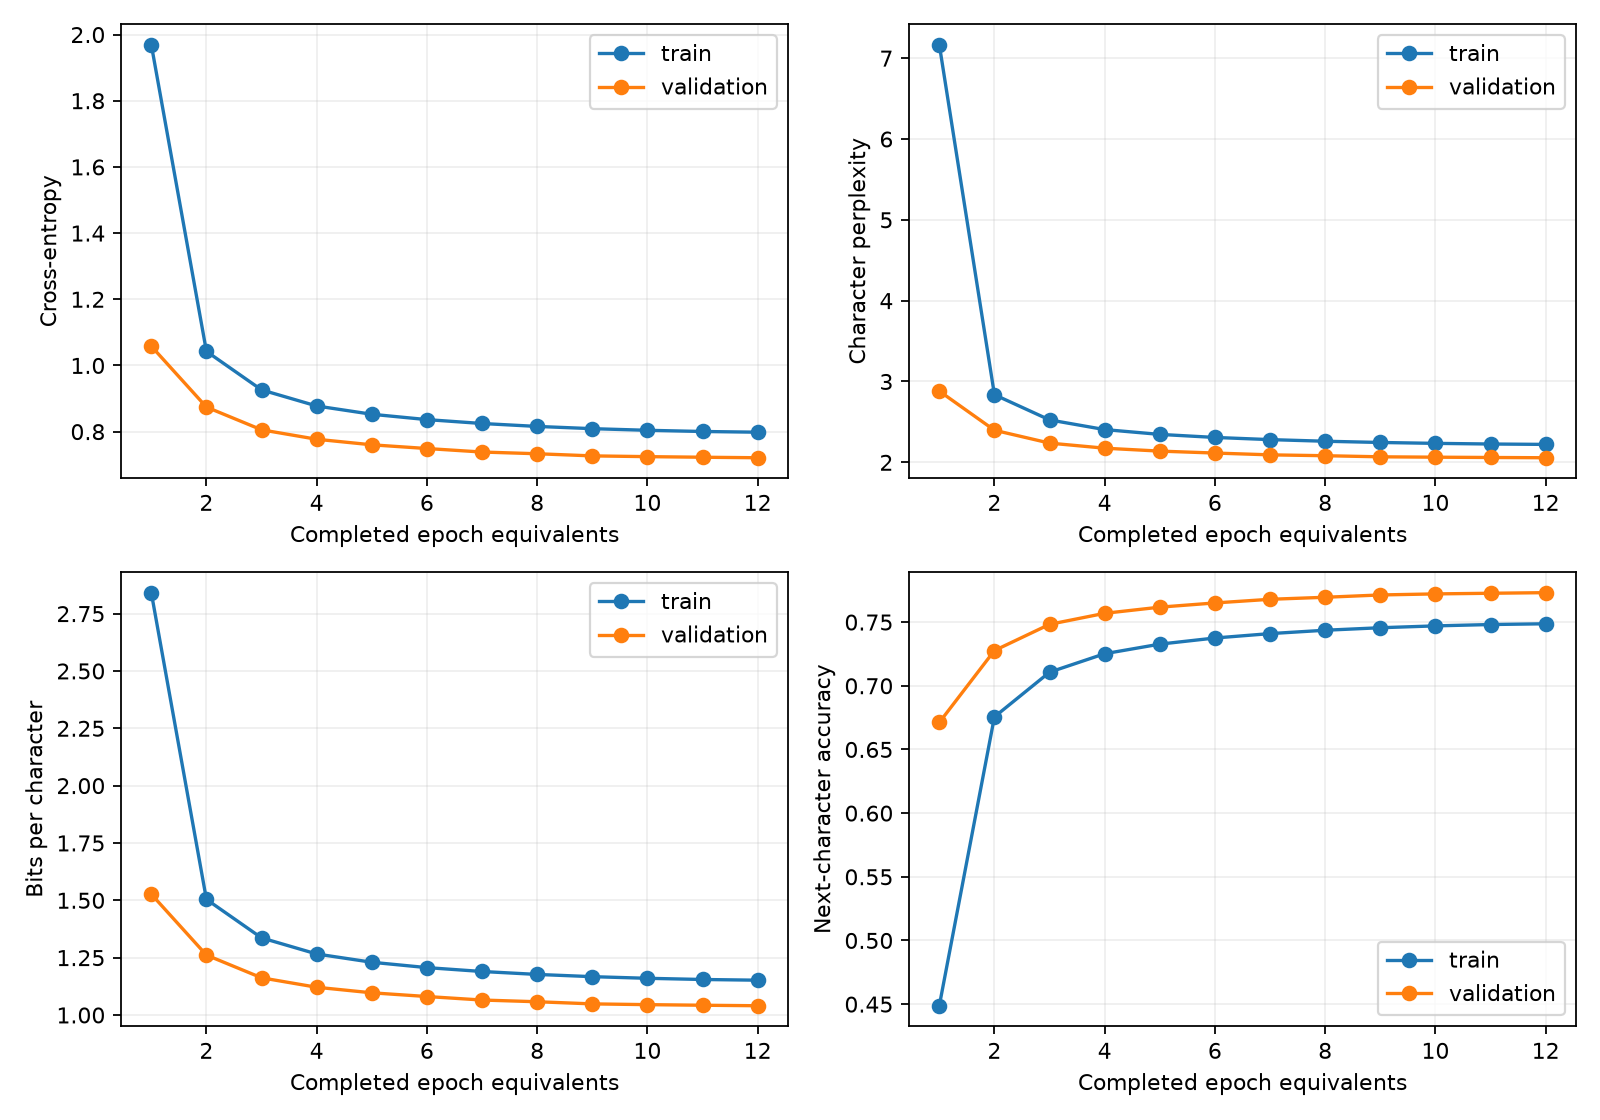

training_diagnostics.png


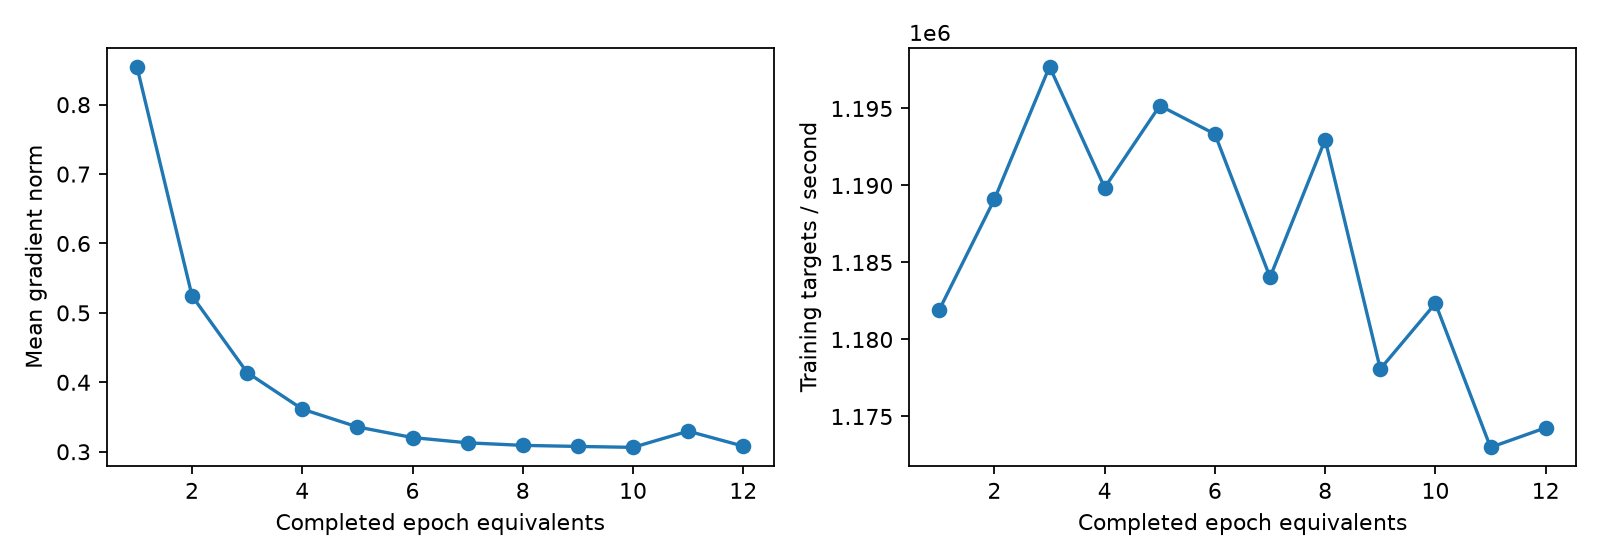

In [4]:
metrics = pd.read_csv(MEMBER / "metrics_report.csv")
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(metrics[["split", "metric", "value"]])
display(pd.DataFrame({"epoch": [row["epoch"] for row in history],
                      "complete": [row["epoch_complete"] for row in history],
                      "train_ce": [row["train"]["cross_entropy"] for row in history],
                      "validation_ce": [row["validation"]["cross_entropy"] for row in history],
                      "validation_perplexity": [row["validation"]["perplexity"] for row in history],
                      "validation_accuracy": [row["validation"]["next_character_accuracy"] for row in history]}))
for figure in sorted((RUN / "figures").glob("*.png")):
    print(figure.name)
    display(Image(filename=str(figure), width=950))

## Preserved raw training output

The complete unedited metrics.jsonl training log is displayed here and included in the package. It records each logged update and every completed epoch. The original local console log is retained unchanged; its startup warnings include host paths, so that console is omitted from the portable package.

In [5]:
print((RUN / "metrics.jsonl").read_text(encoding="utf-8"))

{"kind": "step", "mode": "full", "epoch": 1, "step": 50, "loss": 3.9667952060699463, "gradient_norm_before_clipping": 2.4407811164855957, "learning_rate": 2.1367521367521368e-05, "targets_per_second": 1195766.1769441974, "host_peak_rss_mb": 2269.8984375, "cuda_peak_allocated_mb": 4098.80517578125}
{"kind": "step", "mode": "full", "epoch": 1, "step": 100, "loss": 3.430048942565918, "gradient_norm_before_clipping": 1.8715139627456665, "learning_rate": 4.2735042735042735e-05, "targets_per_second": 1212098.104889144, "host_peak_rss_mb": 2269.90625, "cuda_peak_allocated_mb": 4098.80517578125}
{"kind": "step", "mode": "full", "epoch": 1, "step": 150, "loss": 2.9742915630340576, "gradient_norm_before_clipping": 1.2393401861190796, "learning_rate": 6.410256410256412e-05, "targets_per_second": 1183191.5146895624, "host_peak_rss_mb": 2269.953125, "cuda_peak_allocated_mb": 4098.80517578125}
{"kind": "step", "mode": "full", "epoch": 1, "step": 200, "loss": 2.6497600078582764, "gradient_norm_before

## Actual greedy and temperature-sampled text

Each generation below comes from the saved best validation checkpoint. IDs match failure_analysis.md.

In [6]:
generations = json.loads((RUN / "generations.json").read_text(encoding="utf-8"))
for index, item in enumerate(generations):
    print(f"Generation ID: {index} | {item['decoding']} | temperature={item['temperature']} | top_k={item['top_k']} | seed={item['seed']}")
    print(item["full_text"])
    print()

Generation ID: 0 | greedy | temperature=0.0 | top_k=0 | seed=3342
Once upon a time, a little bird named Timmy went to the park with his mom. They saw a big box of box on the ground. The box was so happy and they went to the box. Timmy was so happy to have a big box of fun with his mom.

Timmy was so happy to have his mom and dad ate the box. He was so

Generation ID: 1 | sampled | temperature=0.8 | top_k=40 | seed=3343
Once upon a time, a little bird named Timmy went to the park. Timmy was very excited, but he couldn't find anything. He had a big hole in the sky. It was big and spoiled. He looked out for a while, but he couldn't find anyone to find him.

Finally thought he could find a funny park. He 

Generation ID: 2 | greedy | temperature=0.0 | top_k=0 | seed=3352
Lily found a small red box. Inside, she saw a big box of box on the ground. She wanted to play with it and see what it was. She wanted to play with it and see what it was.

"Look, Lily, I found a big box!" Ben said. "I fou

# Srinidhi — Part 1 observed generation failures

These cases come from the newly trained desktop RTX 5090 model, selected at
epoch 12 using validation cross-entropy. Generation IDs are zero-based entries
in `outputs/full/generations.json`. This is an AI-assisted analysis for student
review; it does not claim that the student has personally reviewed or defended
the interpretations. Every quoted snippet is verified against the actual saved
continuation.

## Case 1 — repeated sentence

Generation ID: 2

Decoding: greedy, temperature 0, seed 3352. Prompt: `Lily found a small red box. Inside`

```text
She wanted to play with it and see what it was. She wanted to play with it and see what it was.
```

Failure type: repetition.

Observation: the identical sentence appears twice consecutively, adding no new
event or explanation of what Lily finds. This occurs inside the continuation,
before the output-length boundary.

Possible explanation: repeatedly choosing the most likely next character can
reinforce a common phrase. The model's learned distribution and limited context
may also contribute; this run does not isolate their individual effects.

Testable next step: compare greedy decoding with temperature 0.6 and 0.8 at
top-k 40 on the same checkpoint and prompts. Record repeated 4-grams and inspect
coherence, since fewer repetitions alone do not establish better stories.

## Case 2 — incorrect verb form

Generation ID: 7

Decoding: sampled, temperature 0.8, top-k 40, seed 3373.
Prompt: `One rainy day, the dog and the cat`

```text
They saw a loud rainbow and stopped and wanted to saw a park.
```

Failure type: broken grammar.

Observation: after `wanted to`, the model produces the past-tense form `saw`
instead of the base form `see`. The sentence is complete within the saved
continuation, so the grammar error is not caused by truncation. `Loud rainbow`
also shows a questionable combination of sensory descriptions.

Possible explanation: accurate character predictions and familiar word spellings
do not enforce sentence-level grammatical constraints. Temperature sampling
can admit less probable constructions, but one sample cannot demonstrate that
sampling caused the error.

Testable next step: lower temperature to 0.6 while keeping the checkpoint,
top-k, prompts and sampling seeds fixed. Count this verb-form error across the
same sample set and check whether repetition increases.

## Case 3 — incoherent event and object references

Generation ID: 9

Decoding: sampled, temperature 0.8, top-k 40, seed 3383.
Prompt: `The little girl learned that sharing`

```text
She heard a loud noise. It was made of many flours. She took the barn and took a delicious learnt and put it on the boat.
```

Failure type: semantic incoherence.

Observation: `It` appears to refer to the noise, but describing that noise as
made of flours is unexplained. The next action moves from a barn to a boat and
treats `learnt` as a food-like object, without introducing a coherent event.
The text contains familiar words while losing their relationships. These
sentences precede the character cutoff.

Possible explanation: a next-character objective rewards local prediction and
does not explicitly require consistent entities or plausible event links.
Limited model capacity and context are possible contributors, but no controlled
ablation here establishes a cause.

Testable next step: compare a longer context with the current 256-character
context in a separately controlled experiment, holding prompts and decoding
fixed and reporting compute differences. Review event and entity consistency
alongside cross-entropy; a better next-character score alone is insufficient.

The five prompts produce ten continuations, each capped at 256 characters.
Trailing partial words at that imposed boundary are not counted as additional
model failures. Across these continuations, repeated 4-gram rate is 0.2482 for
greedy decoding and 0.0281 for sampling. These are small-sample observations,
not estimated failure rates for all TinyStories. Validation perplexity 2.0567
and next-character accuracy 77.31% therefore coexist with poor story coherence.

The generalization gap compares validation without dropout against online
training with dropout and changing weights. Its negative value should not be
interpreted as a matched evaluation of both splits. The proposed fixes above
have not been tested in this run.


## Saved weights, causal-mask check, and fresh CPU/CUDA inference

Both best and last saved weights are checked against their hashes. The selected model is reconstructed from its checkpoint config in a new process. Changing future tokens must leave earlier logits exactly unchanged. Independently loaded instances must produce identical logits on each available device. CUDA is checked when available; CPU loading is always checked. This verifies portability without retraining.

In [7]:
folder = MEMBER / "checkpoints"
checkpoint_manifest = json.loads((folder / "manifest.json").read_text(encoding="utf-8"))
for name, info in checkpoint_manifest.items():
    assert hashlib.sha256((folder / name).read_bytes()).hexdigest() == info["sha256"]
saved = torch.load(folder / "best.pt", map_location="cpu", weights_only=False)
assert all(torch.isfinite(value).all() for value in saved["model"].values())
verification = {"checkpoint_sha256": checkpoint_manifest["best.pt"]["sha256"], "devices": []}
devices = [torch.device("cpu")] + ([torch.device("cuda")] if torch.cuda.is_available() else [])
for device in devices:
    model = gpt.CharacterGPT(len(saved["vocabulary"]["tokens"]), saved["config"]).to(device).eval()
    model.load_state_dict(saved["model"], strict=True)
    independent = gpt.CharacterGPT(len(saved["vocabulary"]["tokens"]), saved["config"]).to(device).eval()
    independent.load_state_dict(saved["model"], strict=True)
    assert sum(p.numel() for p in model.parameters()) == summary["parameter_count"]
    probe = x[:16].unsqueeze(0).to(device)
    modified = probe.clone()
    modified[:, 8:] = (modified[:, 8:] + 1) % len(saved["vocabulary"]["tokens"])
    with torch.no_grad():
        original_logits, altered_logits = model(probe), model(modified)
        assert torch.equal(original_logits, independent(probe))
        assert torch.equal(original_logits[:, :8], altered_logits[:, :8])
        assert torch.isfinite(original_logits).all()
    prompt = "Once upon a time, a little bird"
    continuation = gpt.generate(model, saved["vocabulary"], prompt, 100, device, seed=2342, temperature=0)
    print(f"Fresh {device} inference; reload logits and causal masking verified:")
    print(prompt + continuation)
    verification["devices"].append({"device": str(device), "reload_logits_identical": True,
                                   "causal_mask_verified": True, "finite_logits": True,
                                   "generated_characters": len(continuation)})
    del independent, model
destination = ROOT / "verification/part1_checkpoint_inference.json"
destination.parent.mkdir(parents=True, exist_ok=True)
destination.write_text(json.dumps(verification, indent=2)+"\n", encoding="utf-8")
print("Both checkpoint hashes verified; fresh inference verification saved.")

Fresh cpu inference; reload logits and causal masking verified:
Once upon a time, a little bird named Timmy went to the park with his mom. They saw a big box of box on the ground. The box was so 


Fresh cuda inference; reload logits and causal masking verified:
Once upon a time, a little bird named Timmy went to the park with his mom. They saw a big box of box on the ground. The box was so 
Both checkpoint hashes verified; fresh inference verification saved.


## Reproduce and demo

From the extracted Part 1 root, install the dependencies and package described in README.md. A quick CPU smoke test uses `python -m lab1.run --task gpt --mode smoke --device cpu`. The complete frozen data split is included: a fresh full run uses `python -m lab1.run --task gpt --mode full --device cuda --set offline=true`. To re-execute only this evidence notebook and package the existing completed run, use `python scripts/finalize_gpt.py --run-dir reproducibility/raw_logs/srinidhi/desktop-20261001/part1-full`. The individual Part 1 bundle is one component of the eventual three-part team Canvas submission. Review the model rationale and observed failure analysis in your own words before the viva.